# 전처리 5단계 — DWI (기상위험지수) 계산 v2

## DWI란?

> 기온·습도·실효습도·풍속을 하나의 숫자로 합친 **기상 위험 점수**입니다.  
> 최종 산불위험지수(P-FFDRI)에서 기상 파트의 핵심 입력값으로 사용합니다.

## 계산 순서

```text
1단계  PreDWI  = sigmoid(2.706 + 0.088×기온 - 0.055×습도 - 0.023×실효습도 - 0.104×풍속)
                → 0~1 연속값  (건조·고온일수록 1에 가까움)

2단계  등급화  = PreDWI를 1~10 등급으로 재분류 (산림청 봄철 기준)

3단계  DWI    = 등급 × RNE  (RNE: 최근 강우 감쇠 효과)
                → 0.1~10 범위  (높을수록 위험)
```

## v2 변경점

- 기존 v1의 Step 1 → Step 2 → Step 3 → 최종 요약 흐름 유지
- 처리 범위를 2025년 2~5월에서 **2020~2025년 2~5월 전체**로 확장
- 월별 파티션 단위로 읽고 저장하여 메모리 사용량 절감
- `weather_scaled` 루트에 `.ipynb`, `.png` 등이 있어도 터지지 않도록 `month=YYYY-MM/*.parquet`만 읽음
- 전체 검증 및 월별 통계는 DuckDB로 수행
- 기존 그래프 유지 + 6개년 연도/월 요약 그래프 추가

## 사용한 파생변수

| 변수 | 출처 | 역할 |
|------|------|------|
| ta_mean | weather_scaled | 일평균기온 |
| hm_mean | weather_scaled | 일평균상대습도 |
| wind_ws_mean | weather_scaled | 일평균풍속 |
| effective_humidity | derived/effective_humidity | 실효습도 |
| rne | derived/rne | 강우효과 |

> 출처: 산림청 FFDRI 알고리즘 설명서 (2026.04.20)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import duckdb
from pathlib import Path
import time, gc, warnings

warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ============================================================
# 0. 프로젝트 루트 탐색
# ============================================================

def find_project_root(start=None):
    # 노트북 실행 위치가 달라도 프로젝트 루트를 찾기 위한 함수
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for path in [start, *start.parents]:
        if (path / '.project-root').exists():
            return path
        if (path / 'preprocessing').exists():
            return path
        if (path / 'processed').exists():
            return path

    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. .project-root 또는 preprocessing 폴더를 확인하세요.')


PROJECT_ROOT = find_project_root()

# 필요 시 여기만 직접 수정하세요.
BASE_PATH = PROJECT_ROOT / 'preprocessing'

SCALED_PATH = BASE_PATH / 'weather_scaled'
EH_PATH     = BASE_PATH / 'derived' / 'effective_humidity'
RNE_PATH    = BASE_PATH / 'derived' / 'rne'
DWI_PATH    = BASE_PATH / 'derived' / 'dwi'
WD_PATH     = BASE_PATH / 'derived' / 'w_d.parquet'
FIG_DIR     = BASE_PATH / 'PREP05'

DWI_PATH.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 2020~2025년 2~5월
MONTHS = [
    f'{year}-{month:02d}'
    for year in range(2020, 2026)
    for month in [2, 3, 4, 5]
]

# 봄철 재분류 기준 (산림청 FFDRI 고정값)
SPRING_BINS   = [0.0, 0.1183, 0.1878, 0.2571, 0.3320,
                 0.4089, 0.4932, 0.5861, 0.6862, 0.7820, 1.001]
SPRING_LABELS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

print('설정 완료')
print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'BASE_PATH    : {BASE_PATH}')
print(f'SCALED_PATH  : {SCALED_PATH}')
print(f'EH_PATH      : {EH_PATH}')
print(f'RNE_PATH     : {RNE_PATH}')
print(f'DWI_PATH     : {DWI_PATH}')
print(f'처리 월 수   : {len(MONTHS)}개')
print(MONTHS[:4], '...', MONTHS[-4:])

설정 완료
PROJECT_ROOT : C:\SKN projects\weather
BASE_PATH    : C:\SKN projects\weather\preprocessing
SCALED_PATH  : C:\SKN projects\weather\preprocessing\weather_scaled
EH_PATH      : C:\SKN projects\weather\preprocessing\derived\effective_humidity
RNE_PATH     : C:\SKN projects\weather\preprocessing\derived\rne
DWI_PATH     : C:\SKN projects\weather\preprocessing\derived\dwi
처리 월 수   : 24개
['2020-02', '2020-03', '2020-04', '2020-05'] ... ['2025-02', '2025-03', '2025-04', '2025-05']


---
## Step 1. 계산 함수 정의

In [5]:
def predwi_spring(ta, hm, eh, ws):
    # 봄철(1~6월) PreDWI 계산. 입력값은 모두 ÷10 스케일 적용된 실제 단위.
    x = 2.706 + 0.088*ta - 0.055*hm - 0.023*eh - 0.104*ws
    return (1.0 / (1.0 + np.exp(-x))).astype('float32')


def reclassify(predwi):
    # PreDWI를 산림청 봄철 기준 1~10 등급으로 재분류.
    return pd.cut(
        predwi,
        bins=SPRING_BINS,
        labels=SPRING_LABELS,
        include_lowest=True
    ).astype('int8')


def read_month_partition(base_path, month, columns=None):
    # Hive partition 폴더 month=YYYY-MM 내부의 parquet 파일만 읽는다.
    # base_path 전체를 읽으면 루트의 .ipynb/.png 때문에 에러가 날 수 있으므로 방어적으로 처리한다.
    base_path = Path(base_path)
    month_path = base_path / f'month={month}'

    if not month_path.exists():
        raise FileNotFoundError(f'월 파티션 폴더가 없습니다: {month_path}')

    parquet_files = sorted(month_path.glob('*.parquet'))

    if len(parquet_files) == 0:
        parquet_files = sorted(month_path.rglob('*.parquet'))

    if len(parquet_files) == 0:
        raise FileNotFoundError(f'Parquet 파일이 없습니다: {month_path}')

    df = pd.read_parquet(
        parquet_files,
        columns=columns,
        engine='pyarrow'
    )

    # partition column이 파일 내부에 없을 수 있으므로 복원
    if 'month' not in df.columns:
        df['month'] = month

    return df


# 시나리오 검증
scenarios = [
    ('극건조 고온',  27.0, 15.0, 12.0, 8.0),
    ('4월 평균적',   15.0, 50.0, 48.0, 2.0),
    ('2월 평균적',    0.0, 60.0, 50.0, 2.0),
    ('비 직후',       8.0, 90.0, 85.0, 2.0),
]

print(f'{"시나리오":<14} {"PreDWI":>8} {"등급":>5}  해석')
print('-' * 50)

for name, ta, hm, eh, ws in scenarios:
    p = float(predwi_spring(np.array([ta]), np.array([hm]),
                             np.array([eh]), np.array([ws]))[0])
    cls = int(pd.cut([p], bins=SPRING_BINS, labels=SPRING_LABELS, include_lowest=True)[0])
    note = '위험' if cls >= 8 else '보통' if cls >= 5 else '안전'
    print(f'{name:<14} {p:>8.4f} {cls:>5}  [{note}]')

시나리오             PreDWI    등급  해석
--------------------------------------------------
극건조 고온           0.9589    10  [위험]
4월 평균적           0.4910     6  [보통]
2월 평균적           0.1243     2  [안전]
비 직후             0.0241     1  [안전]


---
## Step 2. 전체 DWI 계산 (월별)

대용량 데이터이므로 월별 파티션 단위로 처리합니다.  
각 월마다 `weather_scaled`, `effective_humidity`, `rne`를 `grid_id + date` 기준으로 병합한 뒤 DWI를 계산하고, 다시 월별 파티션으로 저장합니다.

In [6]:
start = time.time()

monthly_log = []

for m in MONTHS:
    t0 = time.time()
    print(f'[{m}] 계산 중...', end=' ', flush=True)

    # --------------------------------------------------------
    # 1) 입력 데이터 읽기: 월 파티션 내부 parquet만 읽음
    # --------------------------------------------------------
    df_w = read_month_partition(
        SCALED_PATH,
        m,
        columns=['grid_id', 'date', 'ta_mean', 'hm_mean', 'wind_ws_mean']
    )

    df_eh = read_month_partition(
        EH_PATH,
        m,
        columns=['grid_id', 'date', 'effective_humidity']
    )

    df_rn = read_month_partition(
        RNE_PATH,
        m,
        columns=['grid_id', 'date', 'rne']
    )

    # 날짜 타입 통일
    df_w['date']  = pd.to_datetime(df_w['date'])
    df_eh['date'] = pd.to_datetime(df_eh['date'])
    df_rn['date'] = pd.to_datetime(df_rn['date'])

    # --------------------------------------------------------
    # 2) 병합
    # --------------------------------------------------------
    df = df_w.merge(
        df_eh[['grid_id', 'date', 'effective_humidity']],
        on=['grid_id', 'date'],
        how='inner'
    )

    df = df.merge(
        df_rn[['grid_id', 'date', 'rne']],
        on=['grid_id', 'date'],
        how='inner'
    )

    # --------------------------------------------------------
    # 3) DWI 계산
    # --------------------------------------------------------
    df['predwi'] = predwi_spring(
        df['ta_mean'].values,
        df['hm_mean'].values,
        df['effective_humidity'].values,
        df['wind_ws_mean'].values
    )

    df['predwi_class'] = reclassify(df['predwi'])
    df['dwi'] = (df['predwi_class'].astype('float32') * df['rne'].astype('float32')).astype('float32')

    # --------------------------------------------------------
    # 4) 저장
    # --------------------------------------------------------
    out_dir = DWI_PATH / f'month={m}'
    out_dir.mkdir(parents=True, exist_ok=True)

    out_cols = ['grid_id', 'date', 'predwi', 'predwi_class', 'dwi']
    df[out_cols].to_parquet(
        out_dir / 'data.parquet',
        index=False,
        engine='pyarrow',
        compression='snappy'
    )

    elapsed = time.time() - t0
    avg_dwi = float(df['dwi'].mean())
    high_ratio = float((df['dwi'] >= 8).mean() * 100)

    monthly_log.append({
        'month': m,
        'row_count': len(df),
        'mean_dwi': avg_dwi,
        'high_ratio': high_ratio,
        'elapsed_sec': elapsed
    })

    print(f'완료 ({elapsed:.1f}초)  rows={len(df):,}  avg DWI={avg_dwi:.2f}  고위험={high_ratio:.1f}%')

    del df_w, df_eh, df_rn, df
    gc.collect()

print(f'\n전체: {(time.time()-start)/60:.1f}분')

monthly_log_df = pd.DataFrame(monthly_log)
display(monthly_log_df.head())

[2020-02] 계산 중... 완료 (18.3초)  rows=7,917,029  avg DWI=1.66  고위험=0.7%
[2020-03] 계산 중... 완료 (20.5초)  rows=8,463,031  avg DWI=3.06  고위험=2.4%
[2020-04] 계산 중... 완료 (15.9초)  rows=8,190,030  avg DWI=4.33  고위험=11.8%
[2020-05] 계산 중... 완료 (22.2초)  rows=8,463,031  avg DWI=2.86  고위험=7.9%
[2021-02] 계산 중... 완료 (16.7초)  rows=7,644,028  avg DWI=2.86  고위험=2.7%
[2021-03] 계산 중... 완료 (17.3초)  rows=8,463,031  avg DWI=2.66  고위험=5.2%
[2021-04] 계산 중... 완료 (15.9초)  rows=8,190,030  avg DWI=4.12  고위험=14.4%
[2021-05] 계산 중... 완료 (19.6초)  rows=8,463,031  avg DWI=2.58  고위험=6.0%
[2022-02] 계산 중... 완료 (17.4초)  rows=7,644,028  avg DWI=2.67  고위험=1.5%
[2022-03] 계산 중... 완료 (18.6초)  rows=8,463,031  avg DWI=2.85  고위험=4.0%
[2022-04] 계산 중... 완료 (16.9초)  rows=8,190,030  avg DWI=4.92  고위험=23.8%
[2022-05] 계산 중... 완료 (19.8초)  rows=8,463,031  avg DWI=5.42  고위험=18.0%
[2023-02] 계산 중... 완료 (15.1초)  rows=7,644,028  avg DWI=2.26  고위험=1.5%
[2023-03] 계산 중... 완료 (18.2초)  rows=8,463,031  avg DWI=4.78  고위험=16.9%
[2023-04] 계산 중... 완료 (17.8초) 

,month,row_count,mean_dwi,high_ratio,elapsed_sec
0,2020-02,7917029,1.663831,0.684979,18.347536
1,2020-03,8463031,3.055882,2.382752,20.459430
2,2020-04,8190030,4.330148,11.821129,15.897177
3,2020-05,8463031,2.862534,7.942521,22.245429
4,2021-02,7644028,2.860522,2.717115,16.731166


---
## Step 3. DuckDB 기반 검증

전체 DWI 결과를 pandas로 한 번에 읽지 않고 DuckDB로 직접 집계합니다.

In [7]:
con = duckdb.connect()

dwi_glob = (DWI_PATH / '**' / '*.parquet').as_posix()

print('=== 저장 결과 기본 정보 ===')
basic = con.execute(f"""
    SELECT
        COUNT(*) AS row_count,
        COUNT(DISTINCT grid_id) AS grid_count,
        MIN(CAST(date AS DATE)) AS min_date,
        MAX(CAST(date AS DATE)) AS max_date,
        SUM(CASE WHEN predwi IS NULL THEN 1 ELSE 0 END) AS predwi_null,
        SUM(CASE WHEN predwi_class IS NULL THEN 1 ELSE 0 END) AS class_null,
        SUM(CASE WHEN dwi IS NULL THEN 1 ELSE 0 END) AS dwi_null
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
""").fetchdf()

display(basic)

print('=== DWI 범위 검증 ===')
range_check = con.execute(f"""
    SELECT
        MIN(predwi) AS min_predwi,
        AVG(predwi) AS mean_predwi,
        MAX(predwi) AS max_predwi,
        MIN(predwi_class) AS min_class,
        AVG(predwi_class) AS mean_class,
        MAX(predwi_class) AS max_class,
        MIN(dwi) AS min_dwi,
        AVG(dwi) AS mean_dwi,
        MAX(dwi) AS max_dwi
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
""").fetchdf()

display(range_check)

min_predwi = range_check.loc[0, 'min_predwi']
max_predwi = range_check.loc[0, 'max_predwi']
min_class = range_check.loc[0, 'min_class']
max_class = range_check.loc[0, 'max_class']
min_dwi = range_check.loc[0, 'min_dwi']
max_dwi = range_check.loc[0, 'max_dwi']

all_ok = True
if not (0 <= min_predwi <= max_predwi <= 1):
    print('=> PreDWI 범위 이상: 확인 필요')
    all_ok = False
if not (1 <= min_class <= max_class <= 10):
    print('=> PreDWI 등급 범위 이상: 확인 필요')
    all_ok = False
if not (0 <= min_dwi <= max_dwi <= 10):
    print('=> DWI 범위 이상: 확인 필요')
    all_ok = False

if all_ok:
    print('=> 모든 범위 정상')

=== 저장 결과 기본 정보 ===


,row_count,grid_count,min_date,max_date,predwi_null,class_null,dwi_null
0,197106722,273001,2020-02-01,2025-05-31,0.0,0.0,0.0


=== DWI 범위 검증 ===


,min_predwi,mean_predwi,max_predwi,min_class,mean_class,max_class,min_dwi,mean_dwi,max_dwi
0,0.002623,0.263753,0.960871,1,3.517581,10,0.1,3.308537,10.0


=> 모든 범위 정상


In [8]:
print('=== 월별 DWI 통계 ===')
monthly_stats = con.execute(f"""
    SELECT
        month,
        COUNT(*) AS row_count,
        AVG(predwi) AS mean_predwi,
        AVG(predwi_class) AS mean_class,
        AVG(dwi) AS mean_dwi,
        SUM(CASE WHEN dwi >= 8 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS high_dwi_ratio
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
    GROUP BY month
    ORDER BY month
""").fetchdf()

display(monthly_stats.head(10))

overall_by_month_num = con.execute(f"""
    SELECT
        CAST(substr(month, 6, 2) AS INTEGER) AS month_num,
        AVG(dwi) AS mean_dwi,
        SUM(CASE WHEN dwi >= 8 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS high_dwi_ratio
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
    GROUP BY month_num
    ORDER BY month_num
""").fetchdf()

display(overall_by_month_num)

=== 월별 DWI 통계 ===


,month,row_count,mean_predwi,mean_class,mean_dwi,high_dwi_ratio
0,2020-02,7917029,0.121224,1.774404,1.663830,0.684979
1,2020-03,8463031,0.236374,3.186769,3.055882,2.382752
2,2020-04,8190030,0.342203,4.493887,4.330152,11.821129
3,2020-05,8463031,0.245868,3.236230,2.862535,7.942521
4,2021-02,7644028,0.213766,2.860522,2.860522,2.717115
5,2021-03,8463031,0.208590,2.852343,2.660208,5.231542
6,2021-04,8190030,0.345899,4.524823,4.119896,14.400570
7,2021-05,8463031,0.241036,3.211386,2.581975,6.023078
8,2022-02,7644028,0.198615,2.666799,2.664998,1.543780
9,2022-03,8463031,0.233390,3.171472,2.851705,4.043681


,month_num,mean_dwi,high_dwi_ratio
0,2,2.193728,1.899939
1,3,3.149192,6.179291
2,4,4.290320,16.185779
3,5,3.536682,8.881199


In [9]:
print('=== 변환 후 샘플 3행 ===')
sample_df = con.execute(f"""
    SELECT *
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
    LIMIT 3
""").fetchdf()

display(sample_df)

=== 변환 후 샘플 3행 ===


,grid_id,date,predwi,predwi_class,dwi,month
0,10007_19696,2020-02-01,0.034264,1,1.0,2020-02
1,10008_19691,2020-02-01,0.034398,1,1.0,2020-02
2,10008_19692,2020-02-01,0.034398,1,1.0,2020-02


---
## Step 4. 검증 및 시각화

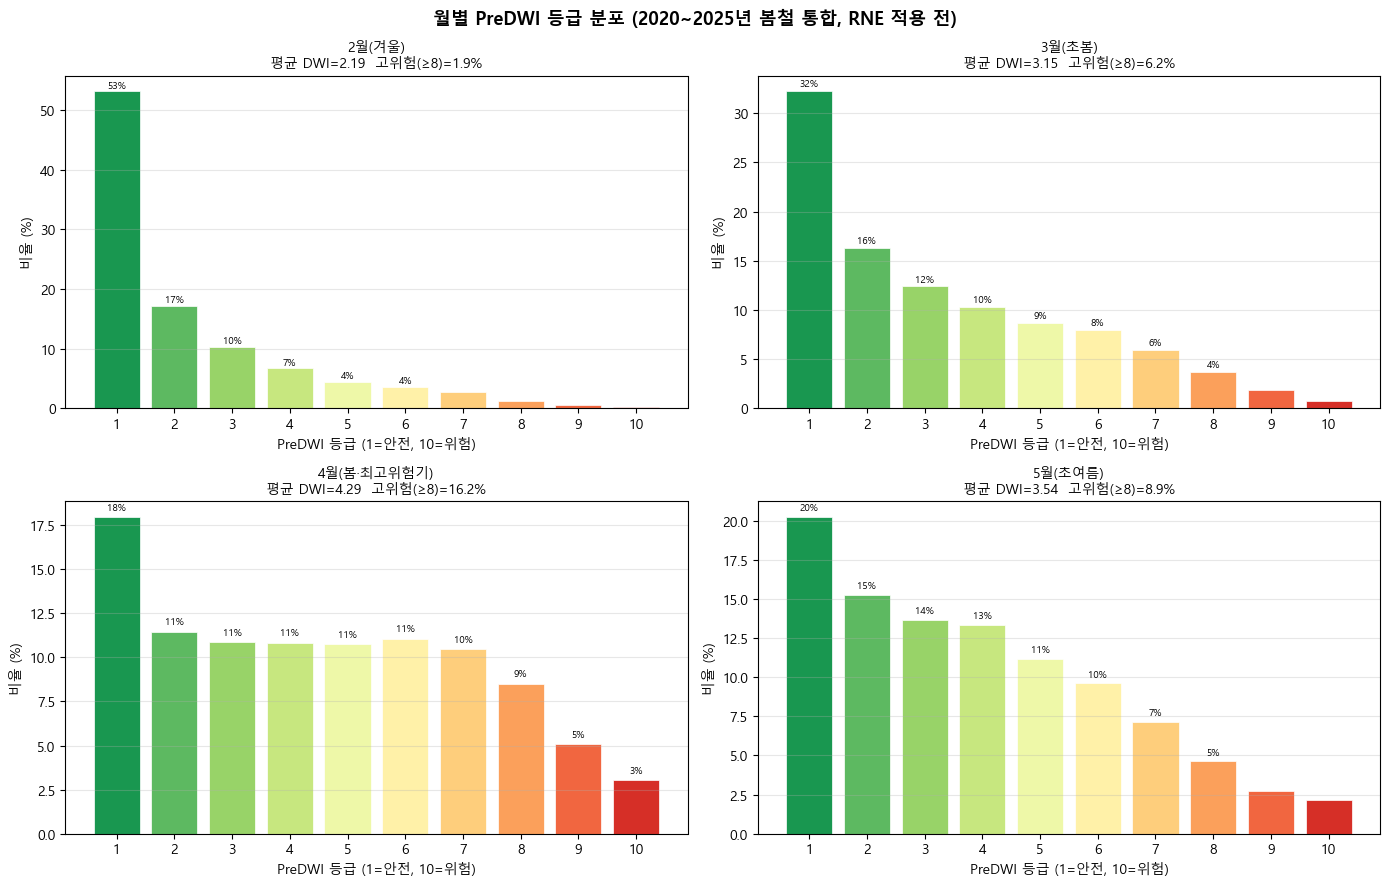

In [10]:
# 월별 DWI 등급 분포 시각화
# 24개월을 한 번에 모두 그리면 너무 복잡하므로, 기본은 월번호(2~5월) 기준 6개년 통합 분포를 그림.

class_month_stats = con.execute(f"""
    SELECT
        CAST(substr(month, 6, 2) AS INTEGER) AS month_num,
        predwi_class,
        COUNT(*) AS cnt
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
    GROUP BY month_num, predwi_class
    ORDER BY month_num, predwi_class
""").fetchdf()

month_summary = con.execute(f"""
    SELECT
        CAST(substr(month, 6, 2) AS INTEGER) AS month_num,
        AVG(dwi) AS mean_dwi,
        SUM(CASE WHEN dwi >= 8 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS high_ratio
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
    GROUP BY month_num
    ORDER BY month_num
""").fetchdf()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
month_kr = {2:'2월(겨울)', 3:'3월(초봄)', 4:'4월(봄·최고위험기)', 5:'5월(초여름)'}
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 10))

for ax, month_num in zip(axes, [2, 3, 4, 5]):
    sub = class_month_stats[class_month_stats['month_num'] == month_num].copy()
    total = sub['cnt'].sum()
    vc = sub.set_index('predwi_class')['cnt'].reindex(range(1, 11), fill_value=0)

    ms = month_summary[month_summary['month_num'] == month_num].iloc[0]
    mean_dwi = ms['mean_dwi']
    high_ratio = ms['high_ratio']

    bars = ax.bar(vc.index, vc.values / total * 100,
                  color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{month_kr[month_num]}\n평균 DWI={mean_dwi:.2f}  고위험(≥8)={high_ratio:.1f}%',
                 fontsize=10)
    ax.set_xlabel('PreDWI 등급 (1=안전, 10=위험)')
    ax.set_ylabel('비율 (%)')
    ax.set_xticks(range(1, 11))
    ax.grid(True, axis='y', alpha=0.3)

    for bar, v in zip(bars, vc.values):
        pct = v / total * 100
        if pct > 3:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{pct:.0f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('월별 PreDWI 등급 분포 (2020~2025년 봄철 통합, RNE 적용 전)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'PREP_05_DWI등급분포_2020_2025.png', dpi=120, bbox_inches='tight')
plt.show()

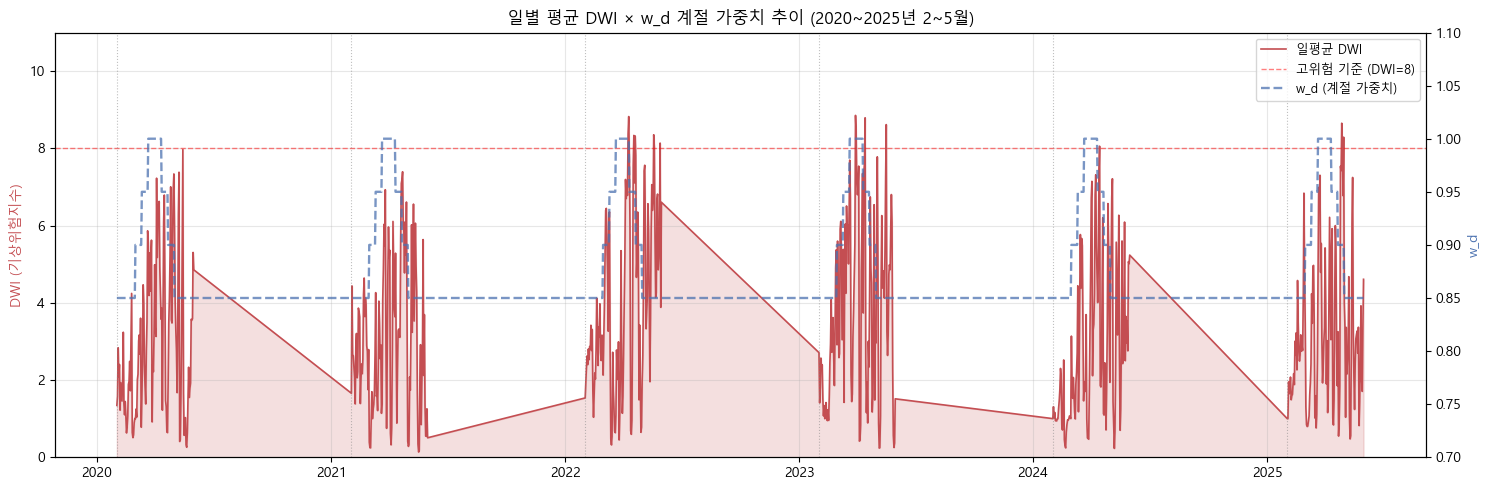

In [11]:
# 일별 평균 DWI 시계열 (전 격자 평균)
# DuckDB로 먼저 일별 평균만 집계한 뒤 pandas 그래프 생성.

daily_dwi = con.execute(f"""
    SELECT
        CAST(date AS DATE) AS date,
        AVG(dwi) AS dwi
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
    GROUP BY date
    ORDER BY date
""").fetchdf()

daily_dwi['date'] = pd.to_datetime(daily_dwi['date'])

# w_d는 6개년용 파일이 있으면 우선 사용하고, 없으면 기존 w_d.parquet 사용
wd_candidates = [
    BASE_PATH / 'derived' / 'w_d_2020_2025.parquet',
    WD_PATH
]

wd_df = None
for p in wd_candidates:
    if p.exists():
        wd_df = pd.read_parquet(p)
        break

if wd_df is not None:
    wd_df['date'] = pd.to_datetime(wd_df['date'])
    wd_df = wd_df[(wd_df['date'] >= daily_dwi['date'].min()) & (wd_df['date'] <= daily_dwi['date'].max())]

fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(daily_dwi['date'], daily_dwi['dwi'],
         color='#C44E52', linewidth=1.2, label='일평균 DWI')
ax1.fill_between(daily_dwi['date'], daily_dwi['dwi'],
                 alpha=0.18, color='#C44E52')
ax1.set_ylabel('DWI (기상위험지수)', color='#C44E52')
ax1.set_ylim(0, 11)
ax1.axhline(8, color='red', linewidth=1, linestyle='--', alpha=0.5, label='고위험 기준 (DWI=8)')

for year in range(2020, 2026):
    ax1.axvline(pd.Timestamp(f'{year}-02-01'), color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

if wd_df is not None and 'w_d' in wd_df.columns:
    ax2 = ax1.twinx()
    ax2.plot(wd_df['date'], wd_df['w_d'],
             color='#4C72B0', linewidth=1.7, linestyle='--', label='w_d (계절 가중치)', alpha=0.75)
    ax2.set_ylabel('w_d', color='#4C72B0')
    ax2.set_ylim(0.7, 1.1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
else:
    ax1.legend(fontsize=9)

ax1.set_title('일별 평균 DWI × w_d 계절 가중치 추이 (2020~2025년 2~5월)', fontsize=12)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'PREP_05_DWI시계열_2020_2025.png', dpi=120, bbox_inches='tight')
plt.show()

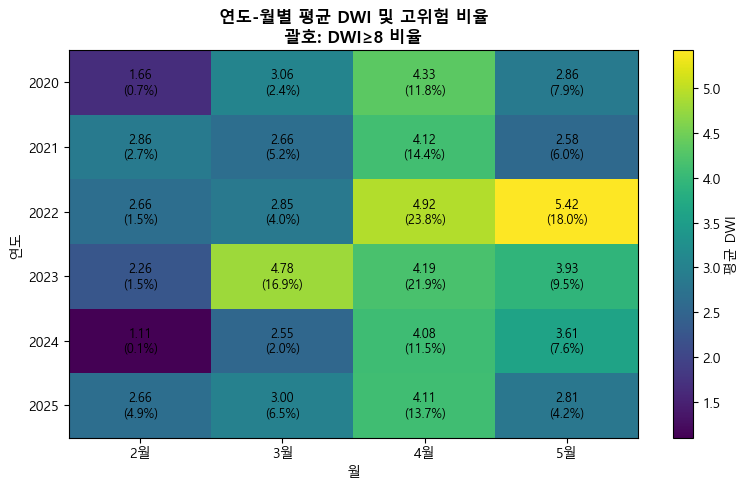

In [12]:
# 연도-월별 평균 DWI heatmap 형태 시각화
# seaborn 없이 matplotlib만 사용.

monthly_stats_plot = monthly_stats.copy()
monthly_stats_plot['year'] = monthly_stats_plot['month'].str.slice(0, 4).astype(int)
monthly_stats_plot['month_num'] = monthly_stats_plot['month'].str.slice(5, 7).astype(int)

pivot_mean = monthly_stats_plot.pivot(index='year', columns='month_num', values='mean_dwi').reindex(columns=[2,3,4,5])
pivot_high = monthly_stats_plot.pivot(index='year', columns='month_num', values='high_dwi_ratio').reindex(columns=[2,3,4,5])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_mean.values, aspect='auto')

ax.set_xticks(range(len(pivot_mean.columns)))
ax.set_xticklabels([f'{m}월' for m in pivot_mean.columns])
ax.set_yticks(range(len(pivot_mean.index)))
ax.set_yticklabels(pivot_mean.index.astype(str))

for i, year in enumerate(pivot_mean.index):
    for j, month_num in enumerate(pivot_mean.columns):
        val = pivot_mean.loc[year, month_num]
        high = pivot_high.loc[year, month_num]
        ax.text(j, i, f'{val:.2f}\n({high:.1f}%)', ha='center', va='center', fontsize=9)

ax.set_title('연도-월별 평균 DWI 및 고위험 비율\n괄호: DWI≥8 비율', fontsize=12, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('연도')
fig.colorbar(im, ax=ax, label='평균 DWI')

plt.tight_layout()
plt.savefig(FIG_DIR / 'PREP_05_DWI연도월히트맵_2020_2025.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 최종 요약

In [13]:
print('=' * 70)
print('  DWI (기상위험지수) 계산 완료')
print('=' * 70)

summary = con.execute(f"""
    SELECT
        COUNT(*) AS row_count,
        COUNT(DISTINCT grid_id) AS grid_count,
        MIN(CAST(date AS DATE)) AS start_date,
        MAX(CAST(date AS DATE)) AS end_date,
        AVG(dwi) AS mean_dwi,
        SUM(CASE WHEN dwi >= 8 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS high_dwi_ratio
    FROM read_parquet('{dwi_glob}', hive_partitioning=true)
""").fetchdf()

row = summary.iloc[0]

summary_text = f"""
  공식 (봄철: 1~6월)
  PreDWI = sigmoid(2.706 + 0.088×기온 - 0.055×습도
                          - 0.023×실효습도 - 0.104×풍속)
  DWI = 재분류등급(1~10) × RNE(0.1~1.0)

  처리 기간
  - {row['start_date']} ~ {row['end_date']}
  - 2020~2025년 2~5월 봄철 전체

  저장 결과
  - 행 수: {int(row['row_count']):,}
  - 격자 수: {int(row['grid_count']):,}
  - 평균 DWI: {row['mean_dwi']:.3f}
  - 고위험(DWI>=8) 격자-날짜 비율: {row['high_dwi_ratio']:.3f}%

  저장 위치
  - {DWI_PATH}
  - 월별 파티션: month=YYYY-MM/data.parquet
  - 컬럼: grid_id, date, predwi, predwi_class, dwi

  생성 그래프
  - {FIG_DIR / 'PREP_05_DWI등급분포_2020_2025.png'}
  - {FIG_DIR / 'PREP_05_DWI시계열_2020_2025.png'}
  - {FIG_DIR / 'PREP_05_DWI연도월히트맵_2020_2025.png'}

  다음 단계
  P-FFDRI = {{7×DWI + 1.5×FMI + 1.5×TMI}} × w_d 형태로 확장 가능
  또는 머신러닝 모델의 기상 위험 파생변수로 dwi/predwi/predwi_class를 활용 가능
"""

print(summary_text)
print('=' * 70)

  DWI (기상위험지수) 계산 완료

  공식 (봄철: 1~6월)
  PreDWI = sigmoid(2.706 + 0.088×기온 - 0.055×습도
                          - 0.023×실효습도 - 0.104×풍속)
  DWI = 재분류등급(1~10) × RNE(0.1~1.0)

  처리 기간
  - 2020-02-01 00:00:00 ~ 2025-05-31 00:00:00
  - 2020~2025년 2~5월 봄철 전체

  저장 결과
  - 행 수: 197,106,722
  - 격자 수: 273,001
  - 평균 DWI: 3.309
  - 고위험(DWI>=8) 격자-날짜 비율: 8.362%

  저장 위치
  - C:\SKN projects\weather\preprocessing\derived\dwi
  - 월별 파티션: month=YYYY-MM/data.parquet
  - 컬럼: grid_id, date, predwi, predwi_class, dwi

  생성 그래프
  - C:\SKN projects\weather\preprocessing\PREP05\PREP_05_DWI등급분포_2020_2025.png
  - C:\SKN projects\weather\preprocessing\PREP05\PREP_05_DWI시계열_2020_2025.png
  - C:\SKN projects\weather\preprocessing\PREP05\PREP_05_DWI연도월히트맵_2020_2025.png

  다음 단계
  P-FFDRI = {7×DWI + 1.5×FMI + 1.5×TMI} × w_d 형태로 확장 가능
  또는 머신러닝 모델의 기상 위험 파생변수로 dwi/predwi/predwi_class를 활용 가능

